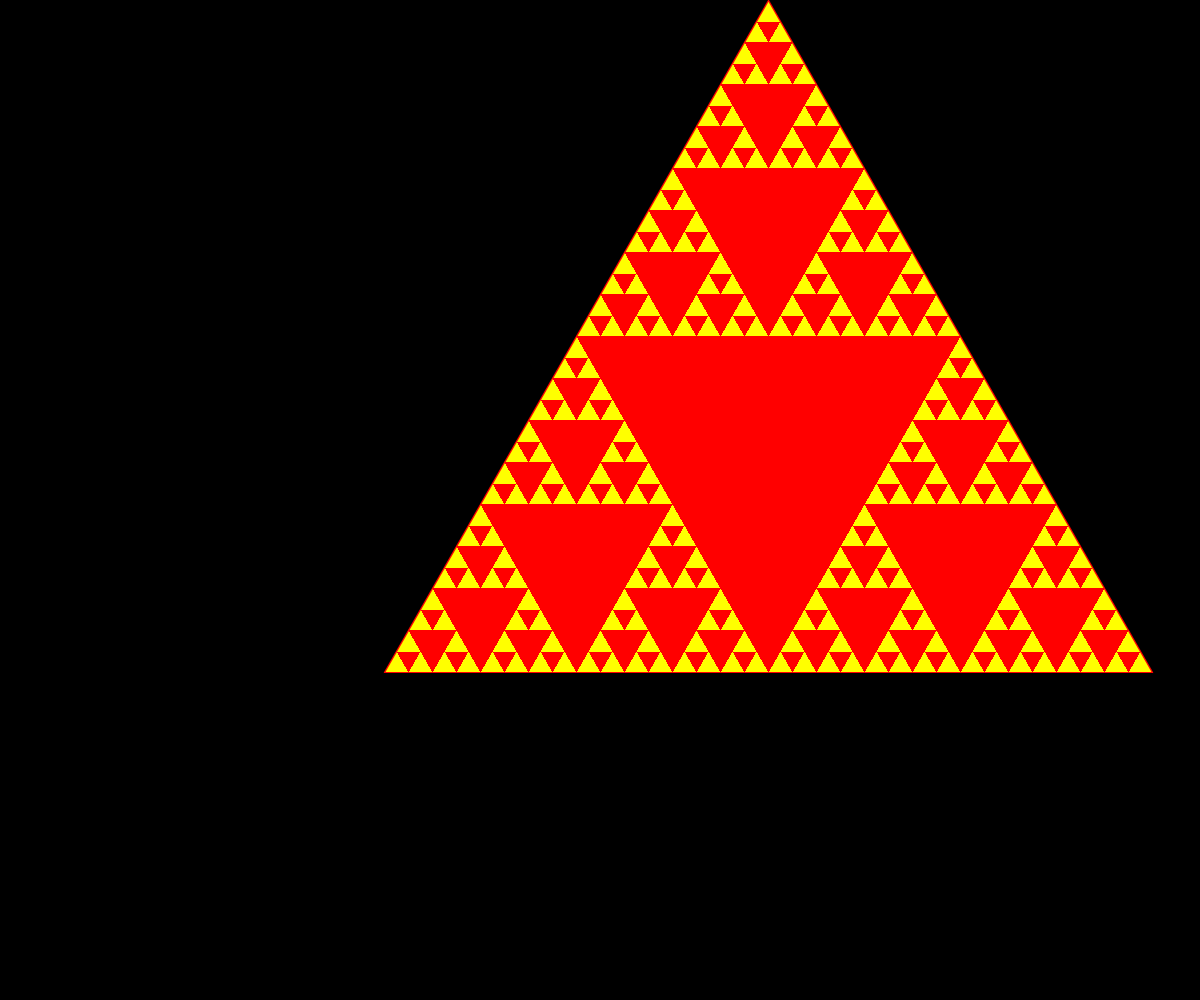

In [1]:
import numpy as np
import cv2
from numba import njit
from google.colab.patches import cv2_imshow

# 1. Setup Canvas Dimensions matching the active loop region bounds
width = 1200
height = 1000

@njit
def render_sierpinski_canvas(img):
    # Mapping Java AWT Colors to OpenCV BGR components
    # Color B: Red -> [0, 0, 255]
    # Color C: Yellow -> [0, 255, 255]
    # Color D: Black -> [0, 0, 0]
    color_b = np.array([0, 0, 255], dtype=np.uint8)
    color_c = np.array([0, 255, 255], dtype=np.uint8)
    color_d = np.array([0, 0, 0], dtype=np.uint8)

    # --- FIRST PASS: BASE TRIANGLE & PATTERN GENERATION ---
    for i in range(300, 1200):
        for j in range(0, 1000):
            if j <= 672 and j >= 1.75 * (i - 768) and j >= (-1.75) * (i - 768):
                if (7 * (i % 24) + 4 * (j % 42) - 168 <= 0 and 7 * (i % 24) - 4 * (j % 42) >= 0) or \
                   ((j % 42) > 21 and (i % 24) <= 24 and (7 * (i % 24) + 4 * (j % 42) - 168 <= 0 or 7 * (i % 24) - 4 * (j % 42) >= 0) and (j % 42) <= 42):
                    img[j, i] = color_b
                else:
                    img[j, i] = color_c
            else:
                img[j, i] = color_d

    # --- SECOND PASS: FRACTAL LEVEL 1 (MODULO 84/48) ---
    for i in range(300, 1200):
        for j in range(0, 1000):
            if j <= 672 and j >= 1.75 * (i - 768) and j >= (-1.75) * (i - 768):
                if (j % 84) <= 84 and (i % 48) <= 48 and (
                    ((j % 84) <= 21 and (j % 84) >= 1.75 * ((i % 48) - 24) and (j % 84) >= -1.75 * ((i % 48) - 24)) or \
                    ((i % 48) <= 48 and (j % 84) <= 63 and ((j % 84) - 63) >= -1.75 * ((i % 48) - 36)) or \
                    ((j % 84) <= 63 and (j % 84) - 42 >= 1.75 * (i % 48))
                ):
                    img[j, i] = color_b

    # --- THIRD PASS: FRACTAL LEVEL 2 (MODULO 168/96) ---
    for i in range(300, 1200):
        for j in range(0, 1000):
            if j <= 672 and j >= 1.75 * (i - 768) and j >= (-1.75) * (i - 768):
                if (j % 168) <= 42 and (j % 168) >= 1.75 * ((i % 96) - 48) and (j % 168) >= -1.75 * ((i % 96) - 48) or \
                   (j % 168) <= 126 and ((j % 168) - 84) >= 1.75 * (i % 96) or \
                   ((j % 168) <= 126 and (i % 96) <= 96 and ((j % 168) - 84) >= -1.75 * ((i % 96) - 96)):
                    img[j, i] = color_b

    # --- FOURTH PASS: FRACTAL LEVEL 3 (MODULO 336/192) ---
    for i in range(300, 1200):
        for j in range(0, 1000):
            if j <= 672 and j >= 1.75 * (i - 768) and j >= (-1.75) * (i - 768):
                if (j % 336) <= 84 and (j % 336) >= 1.75 * ((i % 192) - 96) and (j % 336) >= -1.75 * ((i % 192) - 96) or \
                   (j % 336) <= 252 and ((j % 336) - 168) >= 1.75 * (i % 192) or \
                   ((j % 336) <= 252 and (i % 192) <= 192 and ((j % 336) - 168) >= -1.75 * ((i % 192) - 192)):
                    img[j, i] = color_b

    # --- FIFTH PASS: FRACTAL LEVEL 4 (MODULO 672/384) ---
    for i in range(300, 1200):
        for j in range(0, 1000):
            if j <= 672 and j >= 1.75 * (i - 768) and j >= (-1.75) * (i - 768):
                if (j % 672) <= 168 and (j % 672) >= 1.75 * ((i % 384) - 192) and (j % 672) >= -1.75 * ((i % 384) - 192) or \
                   (j % 672) <= 504 and ((j % 672) - 336) >= 1.75 * (i % 384) or \
                   ((j % 672) <= 504 and (i % 384) <= 384 and ((j % 672) - 336) >= -1.75 * ((i % 384) - 384)):
                    img[j, i] = color_b

# --- Execution Framework Environment ---
img_canvas = np.zeros((height, width, 3), dtype=np.uint8)

# Triggers sequential loop pass processing
render_sierpinski_canvas(img_canvas)

# Vector layer boundary lines matching the trailing section of your Java codebase
color_red = (0, 0, 255)
cv2.line(img_canvas, (768, 0), (384, 672), color_red, 1, cv2.LINE_AA)
cv2.line(img_canvas, (768, 0), (1152, 672), color_red, 1, cv2.LINE_AA)

# Display Canvas Result Window
cv2_imshow(img_canvas)